In [1]:
# Cell 1: Imports

import math
import random
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

{'01': 2546, '11': 2482, '00': 2449, '10': 2523}
Raw QRNG length: 20000


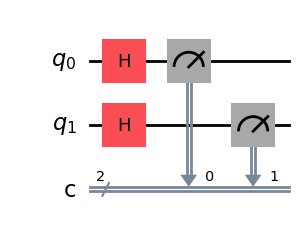

In [2]:
# Cell 2: Generate 2-qubit QRNG bitstream using Qiskit

from qiskit import QuantumCircuit, transpile

try:
    from qiskit_aer import AerSimulator
    simulator = AerSimulator()
except Exception:
    from qiskit.providers.basic_provider import BasicSimulator
    simulator = BasicSimulator()

def generate_qrng_bits(shots=10000):
    qc = QuantumCircuit(2, 2)

    # Create quantum superposition
    qc.h(0)
    qc.h(1)

    # Measure both qubits
    qc.measure([0, 1], [0, 1])

    tqc = transpile(qc, simulator)
    result = simulator.run(tqc, shots=shots).result()
    counts = result.get_counts()

    bitstream = ""
    for outcome, count in counts.items():
        bitstream += outcome * count

    return bitstream, counts, qc

raw_qrng, qrng_counts, circuit = generate_qrng_bits(shots=10000)

print(qrng_counts)
print("Raw QRNG length:", len(raw_qrng))
circuit.draw("mpl")

In [3]:
# Cell 3: Optional degradation model to simulate biased QRNG

def degrade_bitstream(bits, flip_probability=0.08, force_one_probability=0.03, seed=42):
    random.seed(seed)
    degraded = []

    for bit in bits:
        if random.random() < flip_probability:
            bit = "1" if bit == "0" else "0"

        if random.random() < force_one_probability:
            bit = "1"

        degraded.append(bit)

    return "".join(degraded)

degraded_qrng = degrade_bitstream(raw_qrng)

print("Degraded QRNG length:", len(degraded_qrng))
print("First 100 bits:", degraded_qrng[:100])

Degraded QRNG length: 20000
First 100 bits: 1101111101010101010101110101010101010101010101000111010101010110010111010101010111010101010101010101


In [4]:
# Cell 4: Correction Method 1 - Von Neumann Extractor

def von_neumann_extractor(bits):
    extracted = []

    for i in range(0, len(bits) - 1, 2):
        pair = bits[i:i+2]

        if pair == "01":
            extracted.append("0")
        elif pair == "10":
            extracted.append("1")
        # 00 and 11 are discarded

    return "".join(extracted)

vn_qrng = von_neumann_extractor(degraded_qrng)

print("Von Neumann output length:", len(vn_qrng))
print("First 100 corrected bits:", vn_qrng[:100])

Von Neumann output length: 5118
First 100 corrected bits: 0000000000000000000000000100000000000000000000000000000000000100000000000000000000000000000000000000


In [5]:
# Cell 5: Correction Method 2 - Hash Extractor

def hash_extractor(bits, block_size=512, output_bits=256):
    extracted = []

    for i in range(0, len(bits) - block_size + 1, block_size):
        block = bits[i:i+block_size]

        digest = hashlib.sha256(block.encode()).hexdigest()
        digest_bits = bin(int(digest, 16))[2:].zfill(256)

        extracted.append(digest_bits[:output_bits])

    return "".join(extracted)

hash_qrng = hash_extractor(degraded_qrng)

print("Hash extractor output length:", len(hash_qrng))
print("First 100 corrected bits:", hash_qrng[:100])

Hash extractor output length: 9984
First 100 corrected bits: 1000100011101100100111011100011000001010000011101010010110110100000011110111111110011110010010110011


In [6]:
# Cell 6: PRNG bitstream for comparison

def generate_prng_bits(length, seed=123):
    random.seed(seed)
    return "".join(str(random.randint(0, 1)) for _ in range(length))

prng_bits = generate_prng_bits(len(degraded_qrng))

print("PRNG length:", len(prng_bits))
print("First 100 PRNG bits:", prng_bits[:100])

PRNG length: 20000
First 100 PRNG bits: 0101100111000110001010011000000111110111010111110001101110111000101010110100111000100111110001001010


In [7]:
# Cell 7: Randomness metrics

def shannon_entropy(bits):
    counts = Counter(bits)
    total = len(bits)

    entropy = 0
    for count in counts.values():
        p = count / total
        entropy -= p * math.log2(p)

    return entropy

def min_entropy(bits):
    counts = Counter(bits)
    total = len(bits)

    max_probability = max(counts.values()) / total
    return -math.log2(max_probability)

def bit_bias(bits):
    ones = bits.count("1")
    total = len(bits)

    return abs((ones / total) - 0.5)

def autocorrelation(bits, lag=1):
    if len(bits) <= lag:
        return 0

    x = np.array([1 if b == "1" else -1 for b in bits])
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]

def chi_square_test(bits):
    zeros = bits.count("0")
    ones = bits.count("1")
    expected = len(bits) / 2

    chi_square = ((zeros - expected) ** 2 / expected) + ((ones - expected) ** 2 / expected)
    return chi_square

def runs_test(bits):
    runs = 1

    for i in range(1, len(bits)):
        if bits[i] != bits[i - 1]:
            runs += 1

    return runs

def entropy_health_index(bits):
    entropy_score = shannon_entropy(bits)
    bias_score = 1 - min(bit_bias(bits) * 2, 1)
    autocorr_score = 1 - min(abs(autocorrelation(bits)), 1)

    chi = chi_square_test(bits)
    chi_score = 1 / (1 + chi)

    ehi = (
        0.35 * entropy_score +
        0.25 * bias_score +
        0.20 * autocorr_score +
        0.20 * chi_score
    ) * 100

    return ehi

def analyze_stream(name, bits):
    return {
        "Stream": name,
        "Length": len(bits),
        "P(1)": bits.count("1") / len(bits),
        "Bias": bit_bias(bits),
        "Shannon Entropy": shannon_entropy(bits),
        "Min Entropy": min_entropy(bits),
        "Autocorrelation": autocorrelation(bits),
        "Chi-Square": chi_square_test(bits),
        "Runs": runs_test(bits),
        "EHI": entropy_health_index(bits)
    }

results = [
    analyze_stream("Raw QRNG", raw_qrng),
    analyze_stream("Degraded QRNG", degraded_qrng),
    analyze_stream("Von Neumann QRNG", vn_qrng),
    analyze_stream("Hash Extracted QRNG", hash_qrng),
    analyze_stream("PRNG", prng_bits)
]

df = pd.DataFrame(results)
df

,Stream,Length,P(1),Bias,Shannon Entropy,Min Entropy,Autocorrelation,Chi-Square,Runs,EHI
0,Raw QRNG,20000,0.501650,0.001650,0.999992,0.995247,-0.013862,0.217800,10139,96.063042
1,Degraded QRNG,20000,0.516900,0.016900,0.999176,0.952043,-0.017714,22.848800,10166,79.610495
2,Von Neumann QRNG,5118,0.500391,0.000391,1.000000,0.998873,0.794020,0.003126,528,84.037719
3,Hash Extracted QRNG,9984,0.496595,0.003405,0.999967,0.990207,0.012876,0.463141,4928,93.240255
4,PRNG,20000,0.499800,0.000200,1.000000,0.999423,-0.000950,0.003200,10010,99.907196


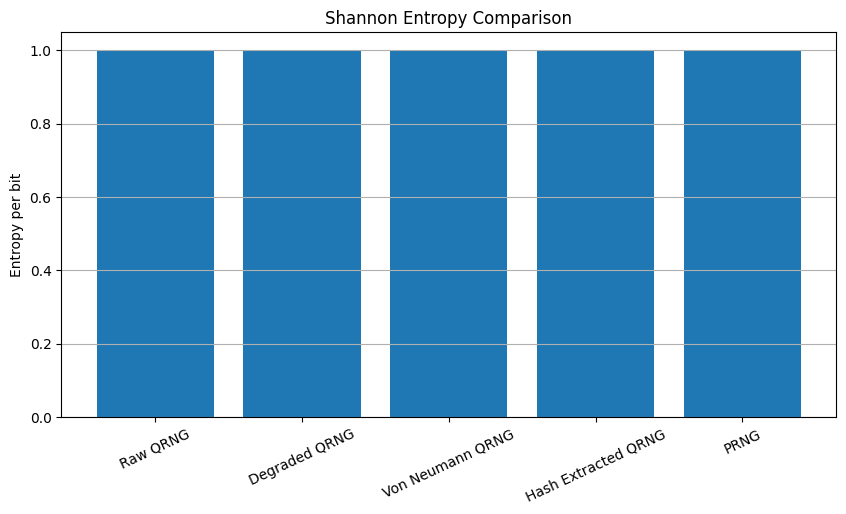

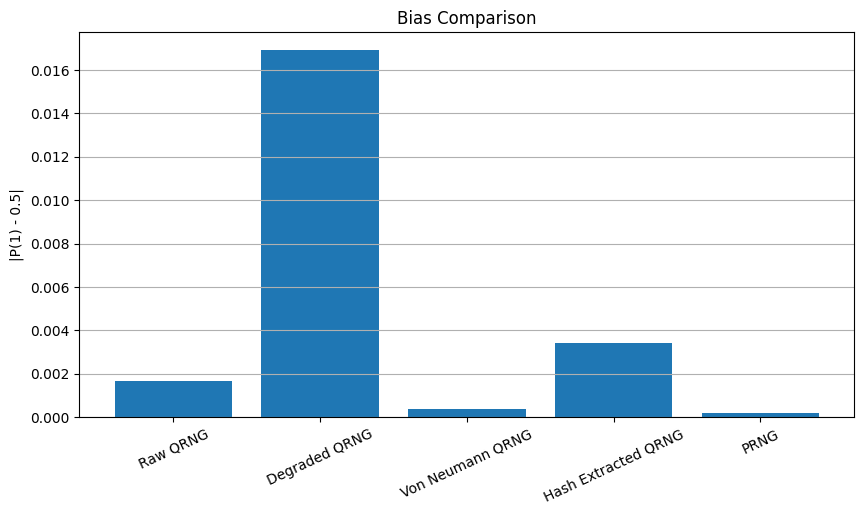

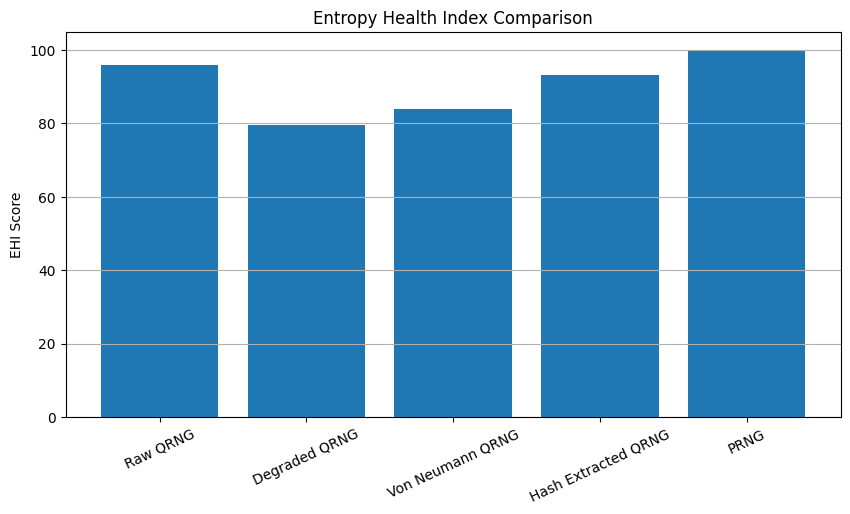

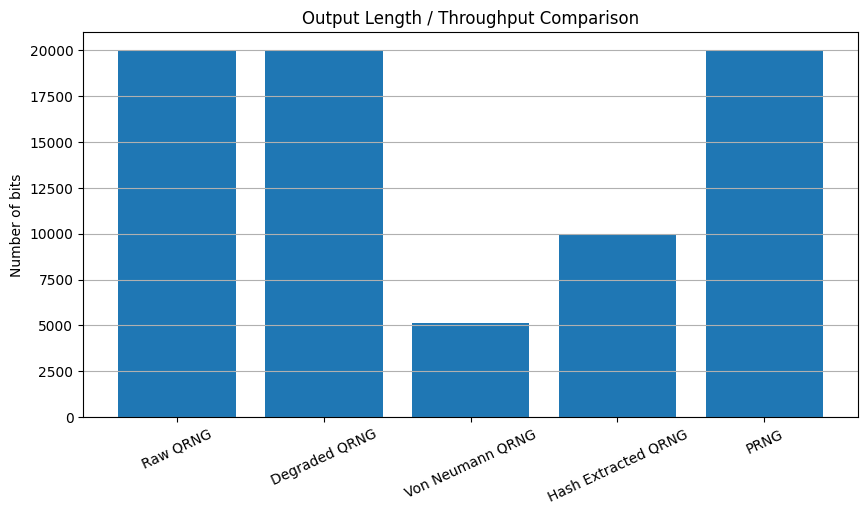

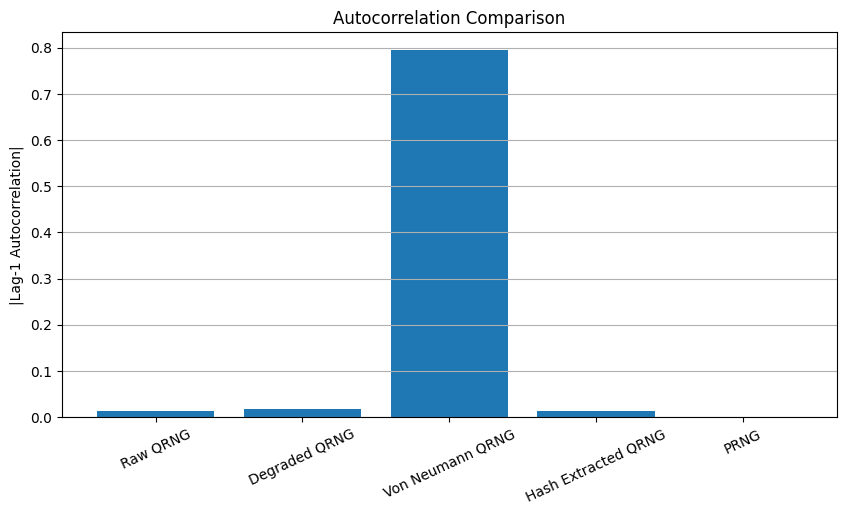

In [8]:
# Cell 8: Graphs for comparison

plt.figure(figsize=(10, 5))
plt.bar(df["Stream"], df["Shannon Entropy"])
plt.title("Shannon Entropy Comparison")
plt.ylabel("Entropy per bit")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["Stream"], df["Bias"])
plt.title("Bias Comparison")
plt.ylabel("|P(1) - 0.5|")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["Stream"], df["EHI"])
plt.title("Entropy Health Index Comparison")
plt.ylabel("EHI Score")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["Stream"], df["Length"])
plt.title("Output Length / Throughput Comparison")
plt.ylabel("Number of bits")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df["Stream"], abs(df["Autocorrelation"]))
plt.title("Autocorrelation Comparison")
plt.ylabel("|Lag-1 Autocorrelation|")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()

In [9]:
# Cell 9: Final conclusion

raw_entropy = df[df["Stream"] == "Degraded QRNG"]["Shannon Entropy"].values[0]
vn_entropy = df[df["Stream"] == "Von Neumann QRNG"]["Shannon Entropy"].values[0]
hash_entropy = df[df["Stream"] == "Hash Extracted QRNG"]["Shannon Entropy"].values[0]

print("Conclusion:")
print("Entropy before correction:", raw_entropy)
print("Entropy after Von Neumann correction:", vn_entropy)
print("Entropy after Hash extraction:", hash_entropy)

if vn_entropy > raw_entropy:
    print("Von Neumann extractor increased entropy.")

if hash_entropy > raw_entropy:
    print("Hash extractor increased entropy.")

print()
print("QRNG vs PRNG:")
print("PRNG may pass statistical tests, but it is deterministic and seed-based.")
print("QRNG is based on quantum measurement, so its randomness is physically generated.")
print("Therefore, corrected QRNG is stronger for true randomness applications.")

Conclusion:
Entropy before correction: 0.9991757467535717
Entropy after Von Neumann correction: 0.999999559380202
Entropy after Hash extraction: 0.9999665376388767
Von Neumann extractor increased entropy.
Hash extractor increased entropy.

QRNG vs PRNG:
PRNG may pass statistical tests, but it is deterministic and seed-based.
QRNG is based on quantum measurement, so its randomness is physically generated.
Therefore, corrected QRNG is stronger for true randomness applications.
